In [1]:
#!/usr/bin/env python
# -*- coding: utf-8 -*-

Names and PRN for all group members:
- Name: ______________________
- PRN:  ______________________
- Date: ______________________

# Image Processing with Neural Network
## A07: Group Assignment


##  Convolutional Neural Network (CNN)

- Flowers Dataset
- Human F1 Score : 0.9375

In [2]:
###-----------------
### Import Libraries
###-----------------
import os
import matplotlib.pyplot as plt
import tensorflow as tf
from utils.helper import fn_plot_tf_hist, fn_plot_confusion_matrix, fn_plot_label


In [3]:
###----------------------
### Some basic parameters
###----------------------

inpDir = '../input' # location where input data is stored
outDir = '../output' # location to store outputs
subDir = 'flower_photos' # location of the images
modelDir = '../models' # location to save model files
valDir = 'valid_flowers' # location related to this dataset
altName = 'students_base_flowers' # Model file name for this alternative

RANDOM_STATE = 24 # for initialization ----- REMEMBER: to remove at the time of promotion to production
tf.random.set_seed(RANDOM_STATE)


EPOCHS = 100   # number of cycles to run
ALPHA = 0.001
BATCH_SIZE = 16
TEST_SIZE = 0.2
IMG_HEIGHT = 190
IMG_WIDTH = 190

# Transformations
# flipping
FLIP_MODE = "horizontal_and_vertical"
# Rotation
ROTATION_FACTOR = (-0.1, 0.1) 
# filling mode
FILL_MODE = 'nearest'


## Early Stopping
ES_PATIENCE = 20 # if performance does not improve stop
# Learning rates
LR_PATIENCE = 10 # if performace is not improving reduce alpha
LR_FACTOR = 0.5 # rate of reduction of alpha


# Set parameters for decoration of plots
params = {'legend.fontsize' : 'large',
          'figure.figsize'  : (15,8),
          'axes.labelsize'  : 'x-large',
          'axes.titlesize'  :'x-large',
          'xtick.labelsize' :'large',
          'ytick.labelsize' :'large',
         }

CMAP = plt.cm.coolwarm

plt.rcParams.update(params) # update rcParams

## Basic Hygiene

In [4]:
###------------------
### Memory Management
###------------------

# physical_devices = tf.config.list_physical_devices('GPU') 

# if len(physical_devices) > 0:
#     tf.config.experimental.set_memory_growth(physical_devices[0], True)
#     print (physical_devices)
# else:
#     print ('Error: No GPU device found')

## Helper Functions
**Note** all helper functions have been moved to util.helper

## Load Dataset

Images are under flower_photos

     |- daisy
     |- dandelion
     |- roses
     |- sunflowers
     |- tulips

In [5]:
'''
    For reading from web link
'''

#import pathlib
#dataset_url = "https://storage.googleapis.com/download.tensorflow.org/example_images/flower_photos.tgz"
#data_dir = tf.keras.utils.get_file(origin=dataset_url,
#                                   fname='flower_photos',
#                                   untar=True)
#data_dir = pathlib.Path(data_dir)
'''
    For reading from local directory
'''
data_dir = os.path.join(inpDir, subDir)

In [6]:
data_dir

'../input\\flower_photos'

In [7]:
# list content of data_dir
os.listdir(data_dir)

['daisy', 'dandelion', 'LICENSE.txt', 'roses', 'sunflowers', 'tulips']

In [8]:
train_ds = tf.keras.preprocessing.image_dataset_from_directory(
    data_dir,
    validation_split=TEST_SIZE,
    subset='training',
    seed= RANDOM_STATE,
    image_size=(IMG_HEIGHT, IMG_WIDTH),
    batch_size=BATCH_SIZE)

test_ds = tf.keras.preprocessing.image_dataset_from_directory(
    data_dir,
    validation_split=TEST_SIZE,
    subset='validation',
    seed= RANDOM_STATE,
    image_size=(IMG_HEIGHT, IMG_WIDTH),
    batch_size=BATCH_SIZE)


Found 3670 files belonging to 5 classes.
Using 2936 files for training.
Found 3670 files belonging to 5 classes.
Using 734 files for validation.


### Is it picking the class names?

In [9]:
class_names = train_ds.class_names
num_classes = len(class_names)
print('total ', num_classes, class_names)

total  5 ['daisy', 'dandelion', 'roses', 'sunflowers', 'tulips']


### Verify the data

To verify that the dataset looks correct, let's plot the first batch from the training set and display the class name below each image.


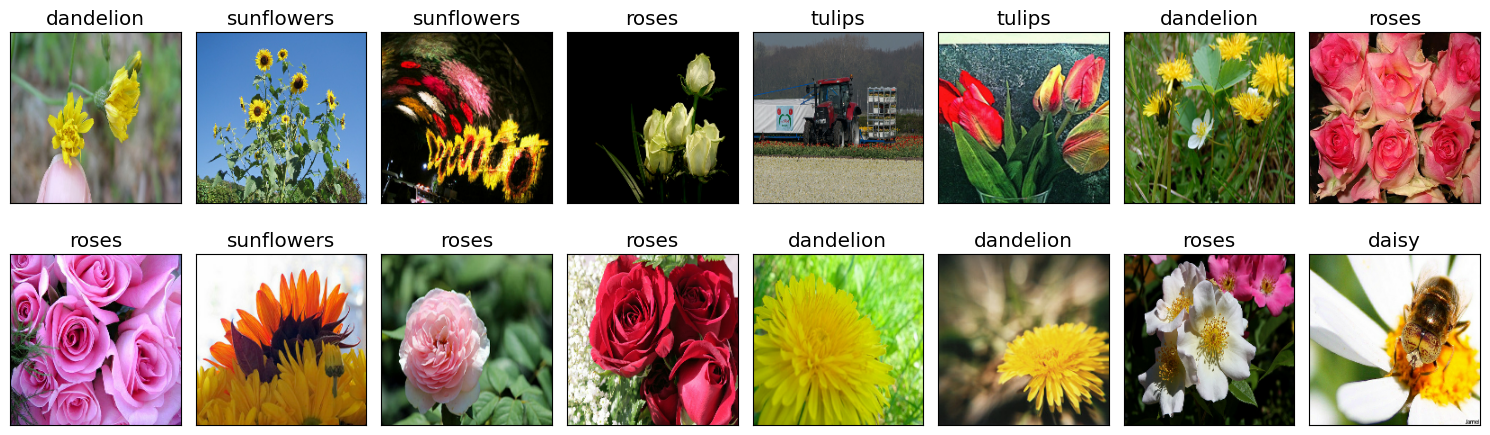

In [10]:
# set figure size
fig = plt.figure(figsize=(15, 5))  # figure size in inches with default params

# Adjust the subplot layout parameters.
fig.subplots_adjust(left=0., # as a fraction of the figure width
                    right=1., # use full width, as a fraction of the figure width
                    bottom=0., # as a fraction of the figure height
                    top=1., # as a fraction of the figure height
                    hspace=0.05, # as a fraction of the average Axes height
                    wspace=0.05) # width of the padding between subplots

# take one batch of the dataset
for images, labels in train_ds.take(1):
    
    # iterate through the batch
    for i in range(BATCH_SIZE):
        
        # add a subplot
        ax = fig.add_subplot( BATCH_SIZE//8, 8, (i+1), xticks=[], yticks=[]) # add a subplot to the figure
        
        # image_size may have converted these images to float
        ax.imshow(images[i].numpy().astype("uint8")) 
        
        # display class in the title
        ax.set_title(class_names[labels[i]])
        
# fit the subplot(s) in to the figure area
plt.tight_layout()
    
# display all open images    
plt.show()

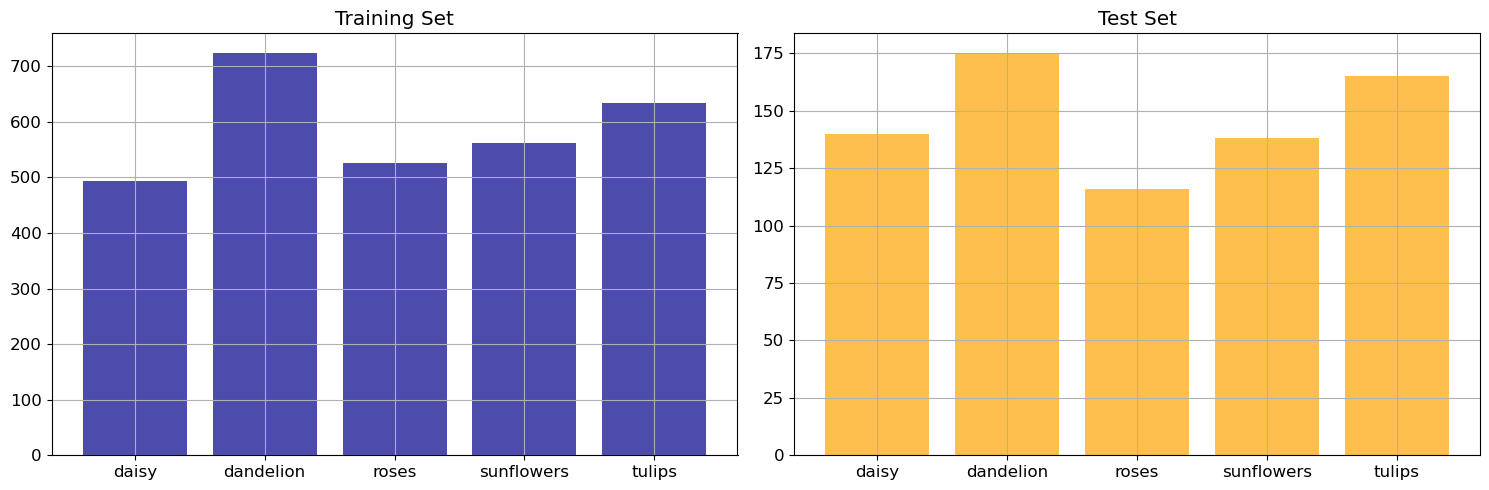

In [11]:
# how many examples in each of the class
fn_plot_label(train_ds, test_ds)

Always start with head of the model (dense layers.)

conv(2,2, 1024) <- max(4,4, 512) <- conv(8,8, 512) <- max(10,10, 256) <- conv(20,20, 256) <- max(22,22, 128) <- conv(44,44, 128) <- max(46,46, 64) <- conv(92,92, 64) <- max(94,94, 32) <- conv(188,188, 32) <-  image(190, 190, 3)

Assumption - we use standard filters -  conv (3,3) stride 1 and Max Pool (2,2) stride 2 and we are using no padding.

Flatten: 4096
Dense: 1024 or 512

In [12]:
images[0].shape

TensorShape([190, 190, 3])

Data is less so use data augmentation.

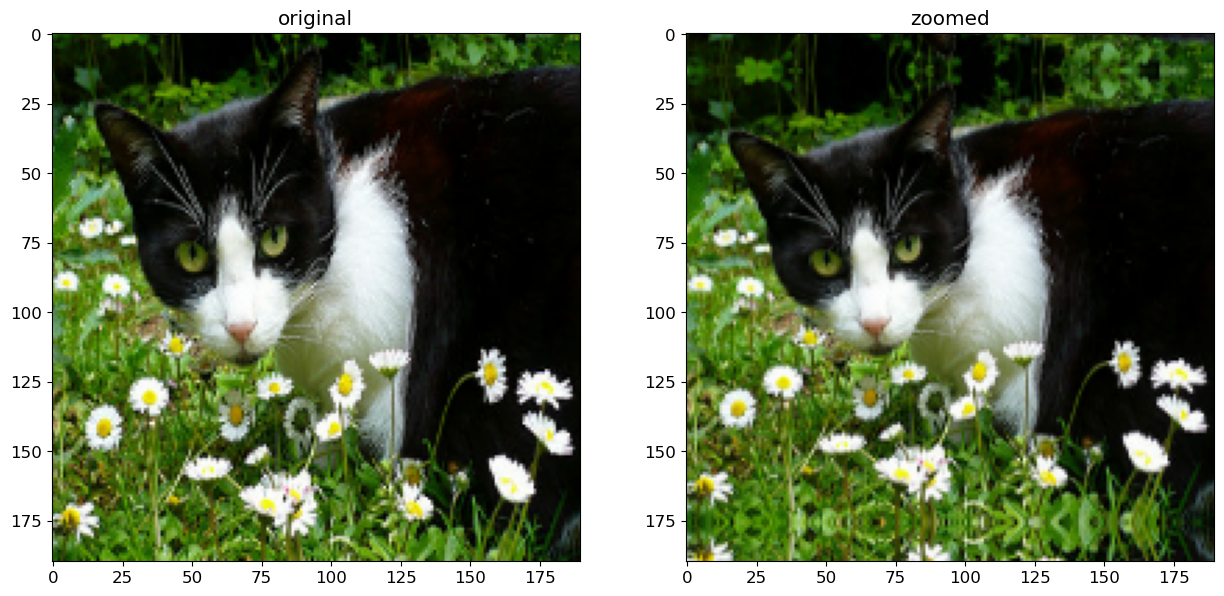

In [13]:
zoom_layer = tf.keras.layers.RandomZoom(height_factor=(-0.2,0.2),
                                            width_factor=(-0.2,0.2))

rng_rotation_layer = tf.keras.layers.RandomRotation((-0.2,0.2), fill_mode='nearest')

plt.figure()
img_num = 0

for imgs, lbls in train_ds.take(1):
    out_imgs = zoom_layer(imgs)

plt.subplot(1,2,1)
plt.title('original')
plt.imshow(imgs[img_num].numpy().astype('uint16'))

plt.subplot(1,2,2)
plt.title('zoomed')
plt.imshow(out_imgs[img_num].numpy().astype('uint16'))

plt.show()

In [14]:
train_ds = train_ds.cache().prefetch(buffer_size=tf.data.AUTOTUNE)
test_ds = test_ds.cache().prefetch(buffer_size=tf.data.AUTOTUNE)

### BUILD MODEL

In [15]:
input_shape = (IMG_HEIGHT, IMG_WIDTH, 3)

In [16]:
def build_model(input_shape, num_classes):
    
    
    ###-----------------------
    ### Define your model here
    ###-----------------------

    model = tf.keras.Sequential()
    model.add(tf.keras.Input(shape=input_shape)) 
    model.add(tf.keras.layers.Rescaling(1./255.))

    ## set 1
    model.add(tf.keras.layers.Conv2D(32, kernel_size=(3,3))) # 188, 188, 32
    model.add(tf.keras.layers.ReLU())
    model.add(tf.keras.layers.MaxPool2D()) # 94, 94, 32

    ## set 2
    model.add(tf.keras.layers.Conv2D(64, kernel_size=(3,3))) # 92, 92, 64
    model.add(tf.keras.layers.ReLU())
    model.add(tf.keras.layers.MaxPool2D()) # 46, 46, 64

    ## set 3
    model.add(tf.keras.layers.Conv2D(128, kernel_size=(3,3))) # 44, 44, 128
    model.add(tf.keras.layers.ReLU())
    model.add(tf.keras.layers.MaxPool2D()) # 22, 22, 128

    ## set 4
    model.add(tf.keras.layers.Conv2D(256, kernel_size=(3,3))) # 20, 20, 256
    model.add(tf.keras.layers.ReLU())
    model.add(tf.keras.layers.MaxPool2D()) # 10, 10, 256

    ## set 5
    model.add(tf.keras.layers.Conv2D(512, kernel_size=(3,3))) # 8, 8, 512
    model.add(tf.keras.layers.ReLU())
    model.add(tf.keras.layers.MaxPool2D()) # 4, 4, 512

    ## set 6
    model.add(tf.keras.layers.Conv2D(1024, kernel_size=(3,3))) # 2, 2, 1024
    model.add(tf.keras.layers.ReLU())

    ## flatten
    model.add(tf.keras.layers.Flatten()) # 4096   # can use global average pooling also here

    # ### head - dense layers
    # model.add(tf.keras.layers.Dense(1024)) # 1024
    # model.add(tf.keras.layers.ReLU())


    model.add(tf.keras.layers.Dense(num_classes))  # num_classes : 5


    
    return model

In [17]:
model = build_model(input_shape=input_shape, num_classes=num_classes)

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rescaling (Rescaling)           │ (None, 190, 190, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 188, 188, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu (ReLU)                    │ (None, 188, 188, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 94, 94, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 92, 92, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_1 (ReLU)                  │ (None, 92, 92, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 46, 46, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 44, 44, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_2 (ReLU)                  │ (None, 44, 44, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 22, 22, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 20, 20, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_3 (ReLU)                  │ (None, 20, 20, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 10, 10, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 8, 8, 512)      │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_4 (ReLU)                  │ (None, 8, 8, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 4, 4, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 2, 2, 1024)     │     4,719,616 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_5 (ReLU)                  │ (None, 2, 2, 1024)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 4096)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 5)              │        20,485 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 6,308,677 (24.07 MB)

 Trainable params: 6,308,677 (24.07 MB)

 Non-trainable params: 0 (0.00 B)

In [18]:
loss_fn = tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True) # loss function
optimizer = tf.keras.optimizers.Adam(learning_rate=ALPHA)   # optimizer
model.compile(optimizer=optimizer, loss=loss_fn, metrics=['accuracy']) # model compilation

In [19]:
# CALLBACKS


# Stops training early if validation loss stops improving to prevent overfitting
es_callback = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=ES_PATIENCE,
    verbose=1,
    restore_best_weights=True  # Fixed typo: restore_best_weight -> restore_best_weights
)


# Reduces learning rate when validation loss plateaus to help convergence
reduce_lr_callback = tf.keras.callbacks.ReduceLROnPlateau(  # Fixed variable name conflict
    monitor='val_loss',
    factor=LR_FACTOR,
    patience=LR_PATIENCE,
    verbose=1,
    mode='auto',
    min_lr=1e-6,
)

In [ ]:
hist = model.fit(train_ds, validation_data=test_ds, 
                    epochs=EPOCHS, callbacks=[reduce_lr_callback, es_callback])

Epoch 1/100
184/184 ━━━━━━━━━━━━━━━━━━━━ 58s 302ms/step - accuracy: 0.3454 - loss: 1.4523 - val_accuracy: 0.5082 - val_loss: 1.3006 - learning_rate: 0.0010
Epoch 2/100
184/184 ━━━━━━━━━━━━━━━━━━━━ 53s 289ms/step - accuracy: 0.5436 - loss: 1.1324 - val_accuracy: 0.5913 - val_loss: 1.0809 - learning_rate: 0.0010
Epoch 3/100
111/184 ━━━━━━━━━━━━━━━━━━━━ 19s 269ms/step - accuracy: 0.5990 - loss: 1.0614

### Reload best Weights for evaluation

### Evaluate the model

## Validate on the validation set

In [ ]:
# data_dir = os.path.join(inpDir, valDir)
# valid_ds = tf.keras.preprocessing.image_dataset_from_directory(
#     data_dir,
#     validation_split=None,
#     #subset='validation',
#     seed= RANDOM_STATE,
#     image_size=(IMG_HEIGHT, IMG_WIDTH),
#     batch_size=BATCH_SIZE)

# valid_ds = valid_ds.cache().prefetch(buffer_size=tf.data.AUTOTUNE)

In [ ]:
# # set figure size
# fig = plt.figure()  # figure size in inches with default params

# # Adjust the subplot layout parameters.
# fig.subplots_adjust(left=0., # as a fraction of the figure width
#                     right=1., # use full width, as a fraction of the figure width
#                     bottom=0., # as a fraction of the figure height
#                     top=1., # as a fraction of the figure height
#                     hspace=0.05, # as a fraction of the average Axes height
#                     wspace=0.05) # width of the padding between subplots
# i = 0
# # take one batch of the dataset
# for images, labels in valid_ds.take(1):
    
#     # iterate through the batch
#     for i in range(BATCH_SIZE):
        
#         # add a subplot
#         ax = fig.add_subplot( BATCH_SIZE//8, 8, (i+1), xticks=[], yticks=[]) # add a subplot to the figure
        
#         # image_size may have converted these images to float
#         ax.imshow(images[i].numpy().astype("uint8")) 
        
#         # display class in the title
#         ax.set_title(class_names[labels[i]])
        
# # fit the subplot(s) in to the figure area
# plt.tight_layout()
    
# # display all open images    
# plt.show()

In [ ]:
# loss, acc = new_model.evaluate(valid_ds)

# print('Accuracy score on Validation Data : {:.3f}%'.format( acc*100))

In [ ]:
# for images, labels in valid_ds.take(2 ):
    
#     # Predict again to keep y_pred in synch with the images
#     yhat = new_model.predict(images, verbose = 0)
    
#     y_pred = yhat.argmax(axis = 1)
#     fontsize = 12
#     fig = plt.figure()  # figure with default size in inches
    
#     fig.subplots_adjust(left=0, right=1, bottom=0, top=1, hspace=0.05, wspace=0.05) # adjust subplots

#     for i in range ( BATCH_SIZE ):
        
#         if labels.numpy()[i]!= y_pred[i]:
#             fc = 'purple'
#             ec="red"
#             text_color = 'yellow'
#         else:
#             fc = 'cyan'
#             ec = 'blue'
#             text_color = 'blue'

#         props = dict(boxstyle='round', facecolor=fc, alpha=0.7, ec = ec)
        
#         ax = fig.add_subplot(BATCH_SIZE // 8 , 8, (i+1), xticks=[], yticks=[]) # add a subplot to the figure
        
#         ax.imshow ( images[i].numpy().astype( "uint8" ) )
        
#         ax.text(0.1, 0.95, class_names[y_pred[i]], transform=ax.transAxes, 
#                 fontsize=fontsize, color = text_color,
#             verticalalignment='top', bbox=props)   # add number (class) of the image

        
#         ax.set_title(class_names[labels.numpy()[i]])
#         #ax.set_title('{} \n {}'.format( class_names[labels.numpy()[i]], ))
        
#         ax.axis("off")
        
#     plt.tight_layout()
    
#     plt.show()